In [72]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [74]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [75]:
# shuffle up words
import random
random.seed(42)
random.shuffle(words)

In [76]:
# Building dataset
block_size = 8 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
    X, Y = [], []
    for w in words:

        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)

    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182580, 8]) torch.Size([182580])
torch.Size([22767, 8]) torch.Size([22767])
torch.Size([22799, 8]) torch.Size([22799])


In [77]:
for x, y in zip(Xtr[:20], Ytr[:20]):
    print(''.join(itos[ix.item()] for ix in x), '-->', itos[y.item()])

........ --> e
.......e --> b
......eb --> r
.....ebr --> i
....ebri --> m
...ebrim --> a
..ebrima --> .
........ --> h
.......h --> i
......hi --> l
.....hil --> t
....hilt --> o
...hilto --> n
..hilton --> .
........ --> j
.......j --> h
......jh --> e
.....jhe --> n
....jhen --> e
...jhene --> .


In [ ]:
# Torchifying code
# This is very familiar to Torch.nn. Look at that to understand tools are there!
class Linear:
    def __init__(self, fan_in, fan_out, bias = True):
        self.weight = torch.randn((fan_in, fan_out)) / fan_in ** 0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    

class BatchNorm1d:

    def __init__(self, dim, eps = 1e-5, momentum = 0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)

        # buffers (trained w a momentum update)
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        # forward pass
        if self.training:
            if x.ndim == 2:
                dim = 0
            if x.ndim == 3:
                dim = (0, 1)
            xmean = x.mean(dim, keepdim = True) # batch mean
            xvar = x.var(dim, keepdim = True) # batch varience

        else:
            xmean = self.running_mean
            xvar = self.running_var
        
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize
        self.out = self.gamma * xhat + self.beta
        # update buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]


class Tanh:

    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []
    

# New classes to further PyTorchify code
    
class Embedding:

    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings, embedding_dim))

    def __call__(self, IX):
        self.out = self.weight[IX]
        return self.out

    def parameters(self):
        return [self.weight]
    
class FlattenConsecutive:

    def __init__(self, n):
        self.n = n

    def __call__(self, x):
        B, T, C = x.shape
        x = x.view(B, T//self.n, C*self.n)

        if x.shape[1] == 1:
            x = x.squeeze(1)

        self.out = x
        return self.out
    
    def parameters(self):
        return []
    
class Sequential:

    def __init__(self, layers):
        self.layers = layers

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out
    
    def parameters(self):
        # get all params from all layers
        return [p for layer in self.layers for p in layer.parameters()]

In [95]:
torch.manual_seed(42); # for reproducability

In [104]:
n_embd = 24 # dimensionality of the embedding vectors
n_hidden = 128 # number of neurons in the hidden layer

model = Sequential([
    Embedding(vocab_size, n_embd),
    FlattenConsecutive(2), Linear(n_embd * 2, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden*2, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden*2, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size)
])

with torch.no_grad():
    # make last layer less confident
    model.layers[-1].weight *= 0.1
    
parameters = model.parameters()
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

76963


In [105]:
# Optimization
num_steps = 200000
batch_size = 32
lossi = []

for i in range(num_steps):

    # minibatch construct for faster training using batches of size 32
    ix = torch.randint(0, Xtr.shape[0], (batch_size, ))
    Xb, Yb = Xtr[ix], Ytr[ix] # Batch X and Y

    # forward pass
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)

    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 150000 else 0.01 # learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # STAT TRACKING
    # print loss every once in a while
    if i % 10000 == 0:
        print(f'{i:7d}/{num_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

# Very slow when training massive models, can use convolutions to speed up as they 
# act as a for loop. Note that these convolutions would be done in cuda and not in python!

      0/ 200000: 3.2863
  10000/ 200000: 1.9470
  20000/ 200000: 1.8098
  30000/ 200000: 2.3780
  40000/ 200000: 1.5580
  50000/ 200000: 2.0799
  60000/ 200000: 1.8675
  70000/ 200000: 1.5475
  80000/ 200000: 1.3445
  90000/ 200000: 1.9302
 100000/ 200000: 2.0975
 110000/ 200000: 2.0298
 120000/ 200000: 1.9203
 130000/ 200000: 1.8458
 140000/ 200000: 1.9491
 150000/ 200000: 1.8841
 160000/ 200000: 1.4931
 170000/ 200000: 1.9994
 180000/ 200000: 1.8011
 190000/ 200000: 2.0011


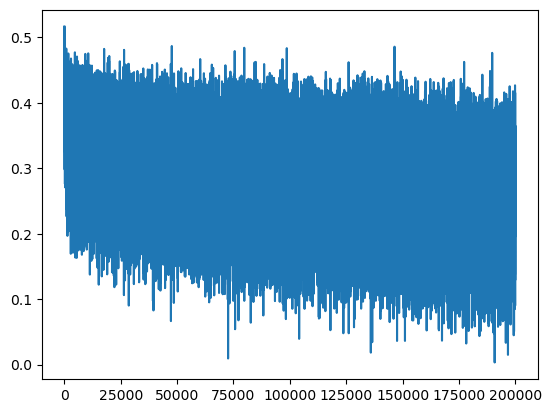

In [106]:
plt.plot(lossi)

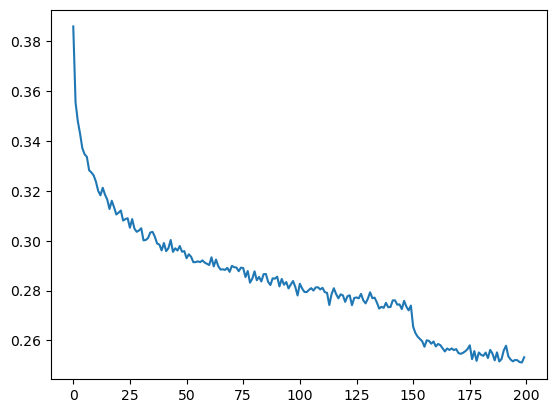

In [107]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

In [108]:
# put layers into eval mode
for layer in model.layers:
    layer.training = False

In [109]:
# evaluate loss
@torch.no_grad() # decorator disables gradient tracking, makes the function much more efficient
def split_loss(split):
    x,y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte)
    }[split]
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())


# Getting overall loss
# Note best loss prev was around 2.10 for val
split_loss('train')
split_loss('val')

train 1.770409345626831
val 1.9863736629486084


In [110]:
for _ in range(20):

    out = []
    context = [0] * block_size # initialization [.] * block_size
    while True:
        # forward pass
        logits = model(torch.tensor([context]))
        probs = F.softmax(logits, dim=1)

        # sample from the distribution
        ix = torch.multinomial(probs, num_samples = 1).item()

        # shift context window and track samples
        context = context[1:] + [ix]
        out.append(ix)
        # if we sample the special token '.', then break
        if ix == 0:
            break
    
    print(''.join(itos[i] for i in out)) #decode and print out the generated word 

bael.
jamarion.
ameline.
tilley.
enol.
musir.
jayxle.
alesandra.
kaidenck.
colby.
zyair.
lianny.
shert.
deonwi.
lamie.
almuala.
kimay.
failah.
keyman.
jalilea.
